In [1]:
%pip install -q "torch==2.3.1" "transformers==4.40.2" pysentiment2 pandas pyarrow tqdm

You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [2]:
try:
    import torch

    if torch.backends.mps.is_available():
        DEVICE = "mps"
    elif torch.cuda.is_available():
        DEVICE = "cuda"
    else:
        DEVICE = "cpu"

    print(f"Using device: {DEVICE}")
except Exception as e:
    print(f"\n[ERROR] {type(e).__name__}: {e}")
    raise SystemExit(1) from None

Using device: mps


In [3]:
try:
    from transformers import AutoTokenizer, AutoModelForSequenceClassification

    TOKENIZER = AutoTokenizer.from_pretrained("ProsusAI/finbert")
    MODEL = AutoModelForSequenceClassification.from_pretrained("ProsusAI/finbert").to(DEVICE)
    MODEL.eval()
    print("FinBERT loaded")
except Exception as e:
    print(f"\n[ERROR] {type(e).__name__}: {e}")
    raise SystemExit(1) from None

/Users/dhruvansh/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/dhruvansh/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/dhruvansh/Library/Python/3.9/lib/python/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/Users/dhruvansh/Library/Python/3.9/lib/python/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will

FinBERT loaded


In [4]:
try:
    import pysentiment2 as ps

    _lm = ps.LM()
    LM_POS = _lm._posset
    LM_NEG = _lm._negset
    print(f"LM word lists loaded: {len(LM_POS)} positive, {len(LM_NEG)} negative words")
except Exception as e:
    print(f"\n[ERROR] {type(e).__name__}: {e}")
    raise SystemExit(1) from None

LM word lists loaded: 140 positive, 893 negative words


In [5]:
try:
    import pandas as pd
    from pathlib import Path

    if not Path("data/raw_news.parquet").exists():
        raise FileNotFoundError("data/raw_news.parquet not found — run notebook_01 first")

    df_news = pd.read_parquet("data/raw_news.parquet")

    null_mask = df_news["headline"].isnull() | (df_news["headline"].str.strip() == "")
    n_dropped = null_mask.sum()
    if n_dropped > 0:
        df_news = df_news[~null_mask].copy()
        print(f"Dropped {n_dropped} rows with null/empty headlines")

    print(f"Loaded {len(df_news)} headlines across {df_news['ticker'].nunique()} tickers")
except Exception as e:
    print(f"\n[ERROR] {type(e).__name__}: {e}")
    raise SystemExit(1) from None

Loaded 73936 headlines across 10 tickers


In [6]:
try:
    def lm_score(text: str) -> float:
        if not isinstance(text, str) or not text.strip():
            return 0.0
        tokens = text.lower().split()
        if not tokens:  # explicit zero-token guard — prevents ZeroDivisionError
            return 0.0
        pos = sum(1 for t in tokens if t in LM_POS)
        neg = sum(1 for t in tokens if t in LM_NEG)
        return max(-1.0, min(1.0, (pos - neg) / len(tokens)))

    print("lm_score defined")
except Exception as e:
    print(f"\n[ERROR] {type(e).__name__}: {e}")
    raise SystemExit(1) from None

lm_score defined


In [1]:
try:
    import torch
    import torch.nn.functional as F

    def finbert_scores(texts: list) -> list:
        def _run_on_device(texts, device):
            inputs = TOKENIZER(
                texts,
                max_length=512,
                truncation=True,
                padding=True,
                return_tensors="pt",
            )
            inputs = {k: v.to(device) for k, v in inputs.items()}
            with torch.no_grad():
                logits = MODEL(**inputs).logits
            probs = F.softmax(logits.cpu(), dim=1).numpy()
            scores = []
            for row in probs:
                idx = int(row.argmax())
                if idx == 0:
                    scores.append(float(row[0]))
                elif idx == 1:
                    scores.append(-float(row[1]))
                elif idx == 2:
                    scores.append(0.0)
                else:
                    print(f"WARNING: unknown FinBERT label {idx}")
                    scores.append(0.0)
            return scores

        try:
            return _run_on_device(texts, DEVICE)
        except NotImplementedError:
            print(f"WARNING: NotImplementedError on {DEVICE}, retrying on CPU")
            return _run_on_device(texts, "cpu")

    print("finbert_scores defined")
except Exception as e:
    print(f"\n[ERROR] {type(e).__name__}: {e}")
    raise SystemExit(1) from None

finbert_scores defined


In [8]:
try:
    import numpy as np
    from tqdm import tqdm

    BATCH_SIZE = 64
    all_finbert = []
    all_lm = []

    headlines = df_news["headline"].fillna("").tolist()

    for start in tqdm(range(0, len(df_news), BATCH_SIZE), desc="Scoring batches"):
        batch_texts = headlines[start : start + BATCH_SIZE]
        all_finbert.extend(finbert_scores(batch_texts))
        all_lm.extend(lm_score(t) for t in batch_texts)

    df_news["finbert_score"] = all_finbert
    df_news["lm_score"] = all_lm
    print(f"Scored {len(df_news)} headlines")
except Exception as e:
    print(f"\n[ERROR] {type(e).__name__}: {e}")
    raise SystemExit(1) from None

Scoring batches: 100%|██████████| 1156/1156 [03:41<00:00,  5.23it/s]

Scored 73936 headlines


In [9]:
try:
    df_news["final_score"] = 0.70 * df_news["finbert_score"] + 0.30 * df_news["lm_score"]

    print("Sample spot-check (3 rows):")
    print(df_news[["headline", "finbert_score", "lm_score", "final_score"]].sample(3).to_string())
except Exception as e:
    print(f"\n[ERROR] {type(e).__name__}: {e}")
    raise SystemExit(1) from None

Sample spot-check (3 rows):
                                                               headline  finbert_score  lm_score  final_score
47941  An old church was given a second life as a stunning events space       0.000000       0.0     0.000000
21838          Man arrested for burglarizing Patriots Gronkowski's home      -0.772522       0.0    -0.540765
71776              Apple says reopening all its branded stores in China       0.000000       0.0     0.000000


In [10]:
try:
    df_daily = (
        df_news.groupby(["date", "ticker"])
        .agg(
            sentiment_score=("final_score", "mean"),
            article_count=("final_score", "count"),
            avg_finbert_score=("finbert_score", "mean"),
            avg_lm_score=("lm_score", "mean"),
        )
        .reset_index()
    )

    df_daily = df_daily[["date", "ticker", "sentiment_score", "article_count", "avg_finbert_score", "avg_lm_score"]]
    df_daily["article_count"] = df_daily["article_count"].astype("int64")
    print(df_daily.shape)
except Exception as e:
    print(f"\n[ERROR] {type(e).__name__}: {e}")
    raise SystemExit(1) from None

(7817, 6)


In [11]:
try:
    import os

    os.makedirs("data", exist_ok=True)
    df_daily.to_parquet("data/sentiment_daily.parquet", index=False)
    print(f"Saved data/sentiment_daily.parquet — {len(df_daily)} stock-day rows")
except Exception as e:
    print(f"\n[ERROR] {type(e).__name__}: {e}")
    raise SystemExit(1) from None

Saved data/sentiment_daily.parquet — 7817 stock-day rows


In [12]:
try:
    df_out = pd.read_parquet("data/sentiment_daily.parquet")
    print(f"Total headlines processed: {len(df_news)}")
    print(f"Stock-day rows in output: {len(df_out)}")
    print(f"Date range: {df_out['date'].min().date()} to {df_out['date'].max().date()}")
except Exception as e:
    print(f"\n[ERROR] {type(e).__name__}: {e}")
    raise SystemExit(1) from None

Total headlines processed: 73936
Stock-day rows in output: 7817
Date range: 2016-01-01 to 2020-04-01


## EDA — Sentiment Analysis Exploratory Plots

/var/folders/4k/v3c36srx6c3gb0ztjb5l3dyr0000gn/T/ipykernel_13344/737874229.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_boxes, labels=tickers_by_median, patch_artist=True,


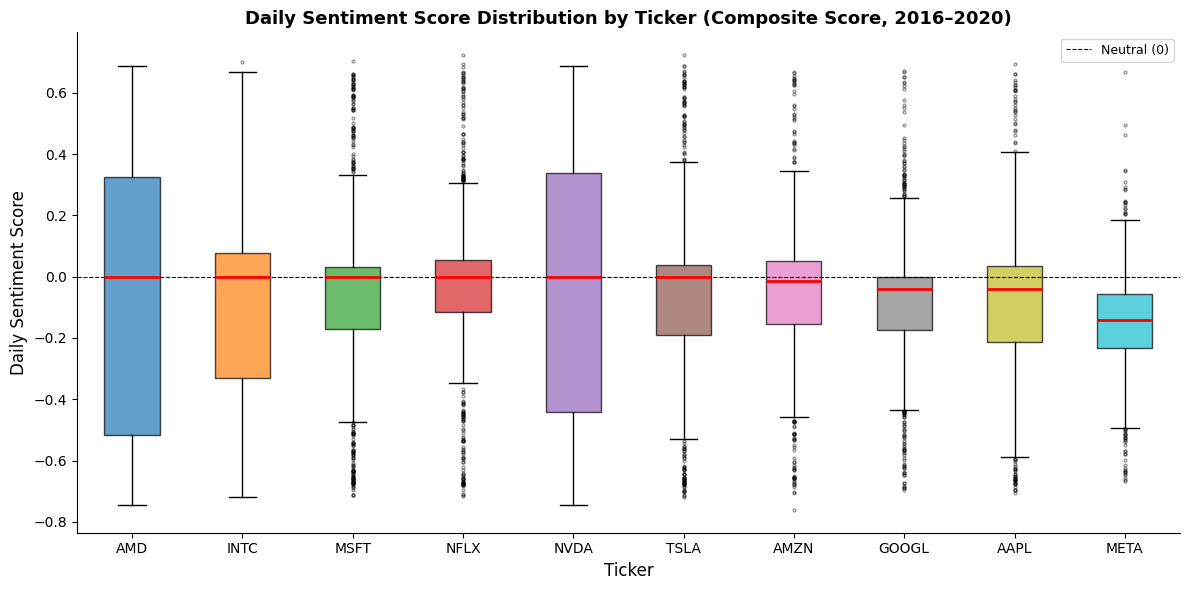

Saved outputs/eda_06_sentiment_distribution_boxplot.png


In [1]:

# EDA 6 — Sentiment Score Distribution per Ticker (box plot)
import matplotlib.pyplot as plt
import pandas as pd
import os

os.makedirs("outputs", exist_ok=True)
df_sent = pd.read_parquet("data/sentiment_daily.parquet")
tickers_by_median = (df_sent.groupby("ticker")["sentiment_score"]
                     .median().sort_values(ascending=False).index.tolist())

fig, ax = plt.subplots(figsize=(12, 6))
data_boxes = [df_sent.loc[df_sent["ticker"] == t, "sentiment_score"].values
              for t in tickers_by_median]
bp = ax.boxplot(data_boxes, labels=tickers_by_median, patch_artist=True,
                medianprops=dict(color='red', linewidth=2),
                flierprops=dict(marker='o', markersize=2, alpha=0.4))
colors = plt.cm.tab10.colors
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.axhline(0, color='black', linestyle='--', linewidth=0.8, label='Neutral (0)')
ax.set_title("Daily Sentiment Score Distribution by Ticker (Composite Score, 2016–2020)",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Ticker", fontsize=12)
ax.set_ylabel("Daily Sentiment Score", fontsize=12)
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig("outputs/eda_06_sentiment_distribution_boxplot.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved outputs/eda_06_sentiment_distribution_boxplot.png")


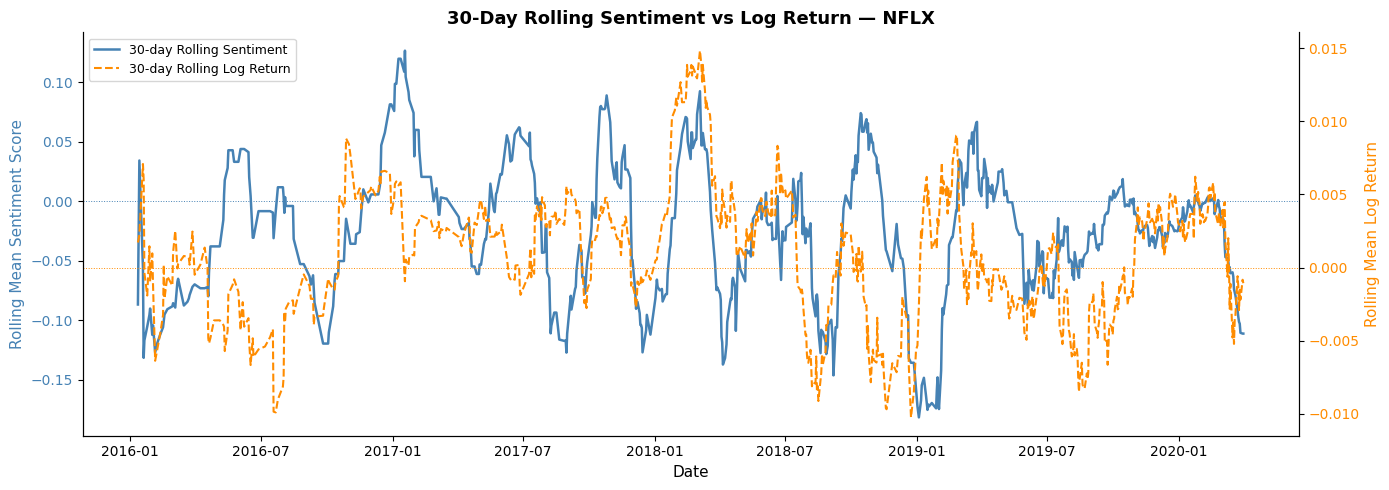

Saved outputs/eda_07_sentiment_vs_return_NFLX.png


In [2]:

# EDA 7 — Rolling 30-day Sentiment vs Price Return for INPUT_TICKER
import matplotlib.pyplot as plt
import pandas as pd

INPUT_TICKER = "NFLX"

df_sent  = pd.read_parquet("data/sentiment_daily.parquet")
df_price = pd.read_parquet("data/raw_prices.parquet")
df_sent["date"]  = pd.to_datetime(df_sent["date"])
df_price["date"] = pd.to_datetime(df_price["date"])

sub_sent  = df_sent[df_sent["ticker"] == INPUT_TICKER].sort_values("date")
sub_price = df_price[df_price["ticker"] == INPUT_TICKER].sort_values("date")

merged = sub_sent.merge(sub_price[["date", "log_return"]], on="date", how="inner")
merged = merged.set_index("date")

roll_sent   = merged["sentiment_score"].rolling(30, min_periods=5).mean()
roll_return = merged["log_return"].rolling(30, min_periods=5).mean()

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

ax1.plot(roll_sent.index, roll_sent, color='steelblue', linewidth=1.8,
         label='30-day Rolling Sentiment')
ax1.axhline(0, color='steelblue', linestyle=':', linewidth=0.7)
ax1.set_ylabel("Rolling Mean Sentiment Score", color='steelblue', fontsize=11)
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2.plot(roll_return.index, roll_return, color='darkorange', linewidth=1.5,
         linestyle='--', label='30-day Rolling Log Return')
ax2.axhline(0, color='darkorange', linestyle=':', linewidth=0.7)
ax2.set_ylabel("Rolling Mean Log Return", color='darkorange', fontsize=11)
ax2.tick_params(axis='y', labelcolor='darkorange')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)
ax1.set_title(f"30-Day Rolling Sentiment vs Log Return — {INPUT_TICKER}",
              fontsize=13, fontweight='bold')
ax1.set_xlabel("Date", fontsize=11)
ax1.spines[['top']].set_visible(False)
ax2.spines[['top']].set_visible(False)
plt.tight_layout()
plt.savefig(f"outputs/eda_07_sentiment_vs_return_{INPUT_TICKER}.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved outputs/eda_07_sentiment_vs_return_{INPUT_TICKER}.png")


In [3]:

# EDA 8 — FinBERT vs LM Score Scatter (coloured by ticker)
import matplotlib.pyplot as plt
import pandas as pd

# Reload df_news if needed (in case kernel restarted after scoring)
try:
    _fb = df_news["finbert_score"]
except NameError:
    raise RuntimeError("Run the scoring cells above first — df_news must be in memory")

import numpy as np
fig, ax = plt.subplots(figsize=(8, 7))
tickers_in_news = df_news["ticker"].unique()
colors = plt.cm.tab10.colors

for idx, t in enumerate(sorted(tickers_in_news)):
    sub = df_news[df_news["ticker"] == t].sample(min(500, len(df_news[df_news["ticker"] == t])),
                                                   random_state=42)
    ax.scatter(sub["lm_score"], sub["finbert_score"],
               alpha=0.25, s=6, color=colors[idx % 10], label=t)

# diagonal line y=x for reference
lim = [-1, 1]
ax.plot(lim, lim, 'k--', linewidth=0.8, label='y = x (equal weight)')
ax.axhline(0, color='grey', linewidth=0.5)
ax.axvline(0, color='grey', linewidth=0.5)
ax.set_xlim(-1, 1)
ax.set_ylim(-1, 1)
ax.set_xlabel("Loughran-McDonald Score", fontsize=12)
ax.set_ylabel("FinBERT Score", fontsize=12)
ax.set_title("FinBERT vs Loughran-McDonald Sentiment Scores per Headline",
             fontsize=13, fontweight='bold')
ax.legend(fontsize=8, ncol=2, markerscale=3)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig("outputs/eda_08_finbert_vs_lm_scatter.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved outputs/eda_08_finbert_vs_lm_scatter.png")


RuntimeError: Run the scoring cells above first — df_news must be in memory